<a href="https://colab.research.google.com/github/Detio1/Deep_Learning/blob/main/Implementing_CNNs_Using_TensorFlow_and_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train: (50000, 32, 32, 3) (50000, 10)
Test:  (10000, 32, 32, 3) (10000, 10)


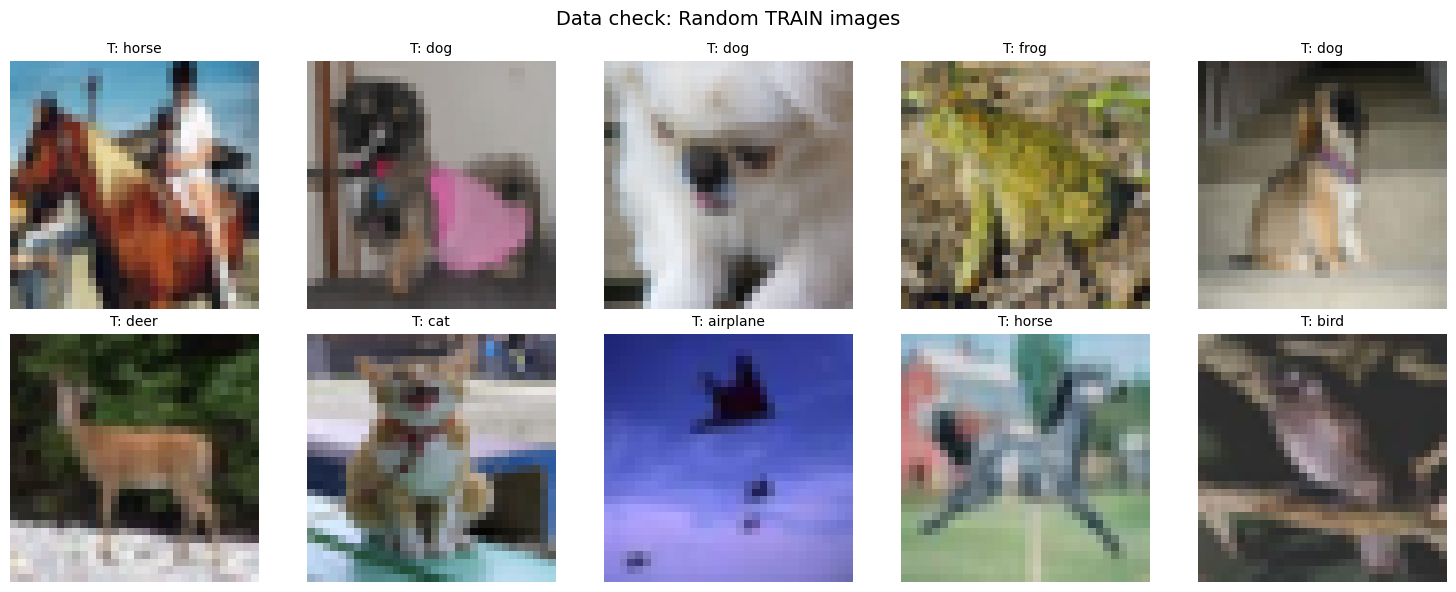

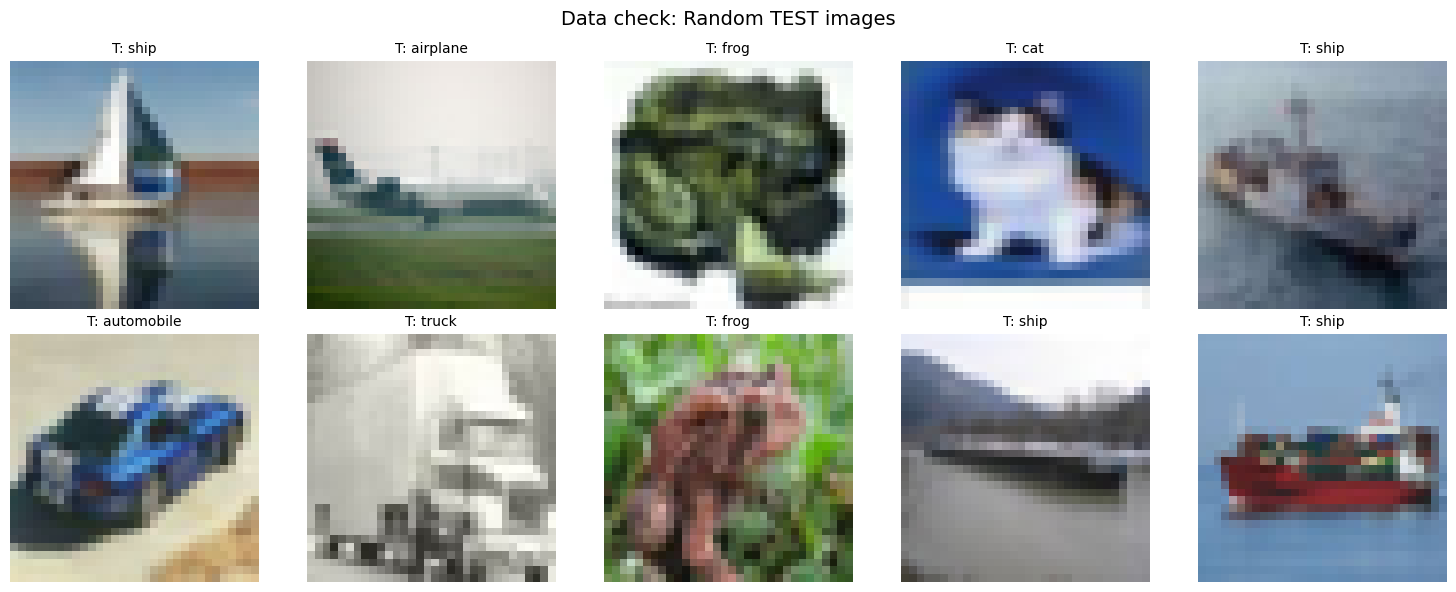

In [ ]:
# Implementing CNNs Using TensorFlow and Keras (Image Classification)
# End-to-end example: data loading -> label encoding -> model -> train -> evaluate -> predict
# ---------------------------
# 1) Import Libraries
# ---------------------------

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


def show_images(images, labels=None, class_names=None, preds=None, probs=None, cols=5, title=None):
    """
    images: (N, H, W, C) float in [0,1] or uint8 in [0,255]
    labels: (N,) true label ints (optional)
    preds : (N,) predicted label ints (optional)
    probs : (N,) confidence for predicted label (optional)
    """
    n = len(images)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))


    plt.figure(figsize=(cols * 3, rows * 3))
    if title:
        plt.suptitle(title, fontsize=14)


    for i in range(n):
        ax = plt.subplot(rows, cols, i + 1)
        img = images[i]
        # If images are normalized floats, imshow is fine. If not, it still works.
        ax.imshow(img)
        ax.axis("off")


        parts = []
        if labels is not None and class_names is not None:
            parts.append(f"T: {class_names[int(labels[i])]}")
        elif labels is not None:
            parts.append(f"T: {int(labels[i])}")


        if preds is not None and class_names is not None:
            conf_txt = ""
            if probs is not None:
                conf_txt = f" ({probs[i]:.2f})"
            parts.append(f"P: {class_names[int(preds[i])]}{conf_txt}")
        elif preds is not None:
            parts.append(f"P: {int(preds[i])}")


        if parts:
            ax.set_title(" | ".join(parts), fontsize=10)


    plt.tight_layout()
    plt.show()



# ---------------------------
# 2) Load Data + Preprocess + Encode Labels
# ---------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

num_classes = 10
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_test_oh  = to_categorical(y_test,  num_classes=num_classes)

print("Train:", x_train.shape, y_train_oh.shape)
print("Test: ", x_test.shape,  y_test_oh.shape)

class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]


# --- NEW: DATA CHECK (visualize a random batch from train + test) ---
np.random.seed(0)
train_idx = np.random.choice(len(x_train), size=10, replace=False)
test_idx  = np.random.choice(len(x_test),  size=10, replace=False)

show_images(x_train[train_idx], labels=y_train[train_idx].flatten(), class_names=class_names,
            cols=5, title="Data check: Random TRAIN images")
show_images(x_test[test_idx], labels=y_test[test_idx].flatten(), class_names=class_names,
            cols=5, title="Data check: Random TEST images")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 162ms/step - accuracy: 0.3798 - loss: 1.6767 - val_accuracy: 0.5200 - val_loss: 1.3259
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.5415 - loss: 1.2837 - val_accuracy: 0.6199 - val_loss: 1.0505
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 159ms/step - accuracy: 0.6094 - loss: 1.1066 - val_accuracy: 0.6755 - val_loss: 0.9361
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.6588 - loss: 0.9741 - val_accuracy: 0.6879 - val_loss: 0.8926
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.6922 - loss: 0.8856 - val_accuracy: 0.7048 - val_loss: 0.8529
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 160ms/step - accuracy: 0.7193 - loss: 0.8116 - val_accuracy: 0.7281 - val_loss: 0.7777
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 100s 160ms/step - accuracy: 0.7391 - loss: 0.7475 - val_accuracy: 0.7334 - val_loss: 0.7701
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.7584 - los

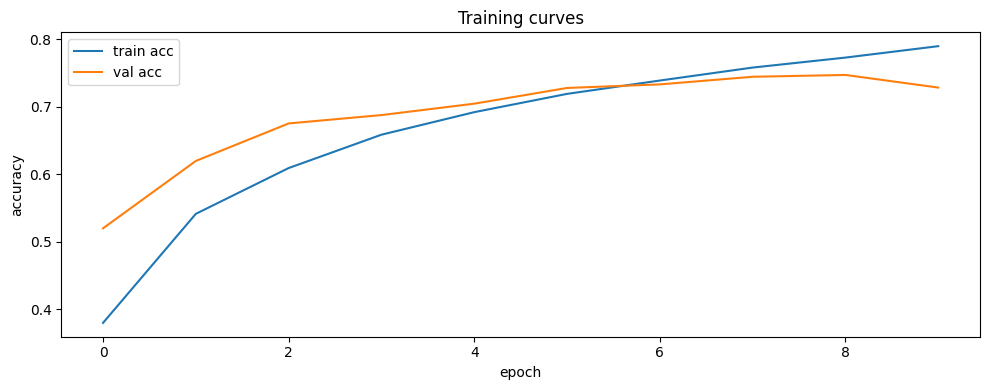


Test Loss: 0.8229 | Test Accuracy: 0.7250

Sample predictions:
True: airplane   | Pred: ship       | Conf: 0.89
True: frog       | Pred: frog       | Conf: 0.88
True: horse      | Pred: horse      | Conf: 0.56
True: frog       | Pred: frog       | Conf: 0.96
True: truck      | Pred: truck      | Conf: 1.00
True: ship       | Pred: ship       | Conf: 1.00
True: dog        | Pred: dog        | Conf: 0.94
True: truck      | Pred: truck      | Conf: 0.92
True: dog        | Pred: cat        | Conf: 0.53
True: frog       | Pred: frog       | Conf: 0.89


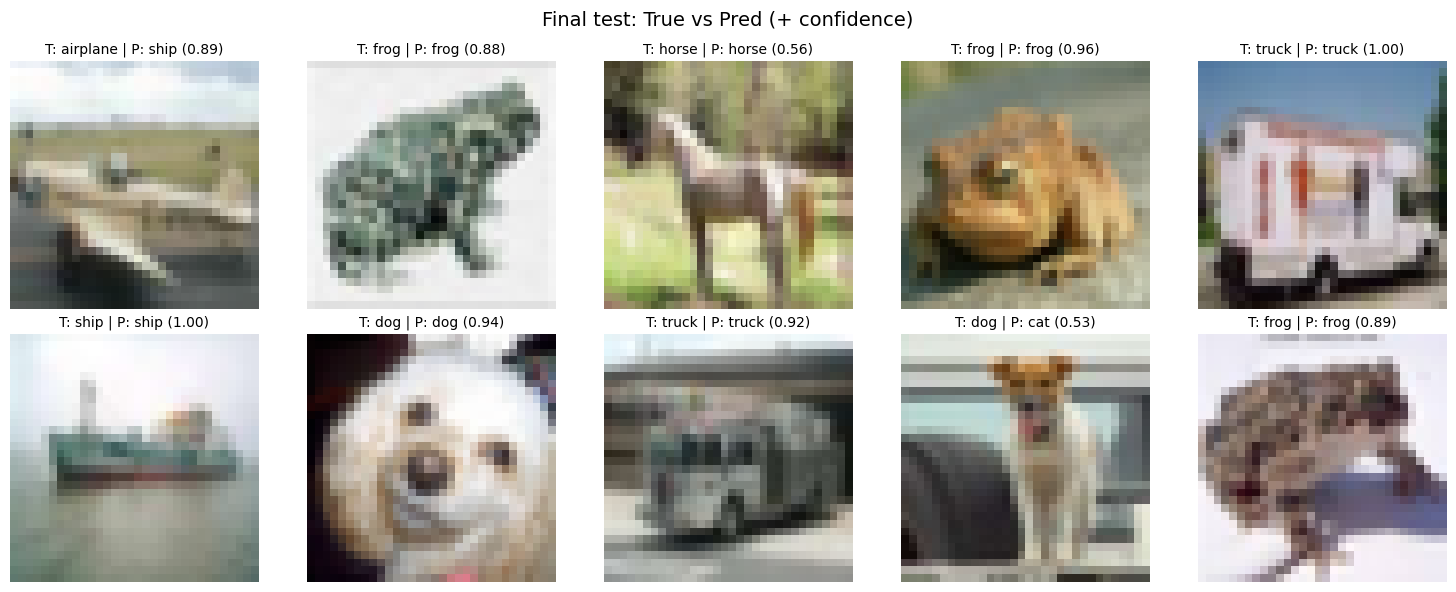

In [ ]:
# ---------------------------
# 3) Define the CNN Architecture
# ---------------------------
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),


    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),


    layers.Flatten(),


    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),


    layers.Dense(num_classes, activation="softmax")
])


model.summary()

# ---------------------------
# 4) Compile the Model
# ---------------------------


model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
# ---------------------------
# 5) Train the Model
# ---------------------------

history = model.fit(
    x_train, y_train_oh,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


# (Optional) quick plot of learning curves (helps visually check training)
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("Training curves")
plt.tight_layout()
plt.show()


# ---------------------------
# 6) Evaluate and Predict (FINAL TEST VISUALIZATION)
# ---------------------------


test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


# Predict on a few test images (and SHOW them)
idx = np.random.choice(len(x_test), size=10, replace=False)
x_sample = x_test[idx]
y_true = y_test[idx].flatten()


probs = model.predict(x_sample, verbose=0)
y_pred = np.argmax(probs, axis=1)
conf = probs[np.arange(len(y_pred)), y_pred]


print("\nSample predictions:")
for i in range(len(idx)):
    print(
        f"True: {class_names[y_true[i]]:10s} | "
        f"Pred: {class_names[y_pred[i]]:10s} | "
        f"Conf: {conf[i]:.2f}"
    )


# --- NEW: FINAL TEST VISUALIZATION ---
show_images(
    x_sample,
    labels=y_true,
    class_names=class_names,
    preds=y_pred,
    probs=conf,
    cols=5,
    title="Final test: True vs Pred (+ confidence)"
)